# **Programming Assignment 2: Regression**

# Name: Musa Kashif
# Roll Number: 28100244

# **Introduction**
In this assignment, you will be designing Linear and Logistic Regression models for the provided datasets from scratch. A description of the problem statement is given at the start of each part. After completing this PA, you should be able to:

- Understand the difference between linear regression and logistic regression

- Implement linear regression from scratch using ordinary least squares

- Implement logistic regression from scratch using gradient descent

- Evaluate models using appropriate regression and classification metrics

- Compare your implementations with scikit-learn
<br>

# **Instructions**
- Follow along with the notebook, filling out the necessary code where instructed.

- <span style="color: red;">Make sure to run all cells for credit.</span>

- <span style="color: red;">Do not remove any pre-written code unless explicitly mentioned.</span>

- <span style="color: red;">Feel free to insert additional code cells.</span>

- <span style="color: red;">You must attempt all parts.</span>

---
# **Submission Checklist**

Before submitting, confirm that:
- All `TODO` cells are filled in

- All plots are visible and labeled

- All written answers are filled in

- The notebook runs top-to-bottom without errors (`Kernel → Restart & Run All`), and every cell's output is visible

- The notebook is saved as `Rollnumber_PA2.ipynb` and submitted zipped in a folder titled `Rollnumber_PA2`

**Good luck! 🥐**

---

# **<span style="color:#008080;">1. Predicting Building Energy Efficiency with Linear Regression — 50 Marks</span>**

In this section, you'll build a **Linear Regression model** to predict a building's **Heating Load** — the amount of energy needed to heat it — based on its physical characteristics like **wall area**, **roof area**, and **overall height**.

**Allowed Libraries:**
- From-scratch implementation: `numpy`, `pandas`, `matplotlib`, `mpl_toolkits`. Only `sklearn.model_selection.train_test_split` from `sklearn`.

- Scikit-learn implementation: `scikit-learn`.

## **1.1 Understanding the Energy Efficiency Dataset**

This dataset was compiled by Angeliki Xifara and processed by Athanasios Tsanas at the University of Oxford. It simulates **768 buildings** with varying architectural parameters, measuring the resulting energy demands.

The goal is to predict **Heating Load (HL)** — the continuous target variable representing how much energy (in kWh/m²) is needed to maintain a comfortable indoor temperature.
<br><br>

**Features:**

| Column | Description |
|---|---|
| <span style="color:#6baed6;">Relative Compactness</span> | Ratio of the building's surface to its volume. More compact = less exposed surface. |
| <span style="color:#6baed6;">Surface Area (m²)</span> | Total outer surface area of the building. |
| <span style="color:#6baed6;">Wall Area (m²)</span> | Total wall surface area. |
| <span style="color:#6baed6;">Roof Area (m²)</span> | Total roof surface area. |
| <span style="color:#6baed6;">Overall Height (m)</span> | Height of the building (3.5m or 7m only). |
| <span style="color:#6baed6;">Orientation</span> | Building orientation (2=North, 3=East, 4=South, 5=West). |
| <span style="color:#6baed6;">Glazing Area (%)</span> | Percentage of floor area that is glass/windows. |
| <span style="color:#6baed6;">Glazing Area Distribution</span> | How glazing is distributed across surfaces (0–5). |
| <span style="color:#f4a261;">Heating Load (target)</span> | Energy required to heat the building (kWh/m²). |

<br><br>
**Start by importing the required libraries:**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
!pip install openpyxl

DATA_PATH = "ENB2012_data.xlsx"  # change if needed

Defaulting to user installation because normal site-packages is not writeable


## **1.2 Exploratory Data Analysis — 10 Marks**

### **1.2.1 Data Loading and Cleaning — 3 Marks**
- Load the Excel file into a pandas DataFrame using `pd.read_excel()`.
- Rename the columns to: `['compactness', 'surface_area', 'wall_area', 'roof_area', 'height', 'orientation', 'glazing_area', 'glazing_dist', 'heating_load', 'cooling_load']`.
- Drop the `cooling_load` column — we won't need it.
- Check for and handle any missing values.
- Print the shape of the DataFrame and the first 5 rows.

In [29]:
df = pd.read_excel(DATA_PATH)

df.columns = [
    'compactness', 'surface_area', 'wall_area', 'roof_area', 'height',
    'orientation', 'glazing_area', 'glazing_dist', 'heating_load', 'cooling_load'
]

df.drop(columns=['cooling_load'], inplace=True)

print(df.isnull().sum())
df.dropna(inplace=True)

print(df.shape)
df.head()

compactness     0
surface_area    0
wall_area       0
roof_area       0
height          0
orientation     0
glazing_area    0
glazing_dist    0
heating_load    0
dtype: int64
(768, 9)


,compactness,surface_area,wall_area,roof_area,height,orientation,glazing_area,glazing_dist,heating_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### **1.2.2 Scatter Plots — 3 Marks**
Create scatter plots of `heating_load` vs **each** of the following features:
- `compactness`

- `surface_area`

- `wall_area`

- `roof_area`

- `height`

- `glazing_area`
<br>

Each plot should have labeled axes and a title.

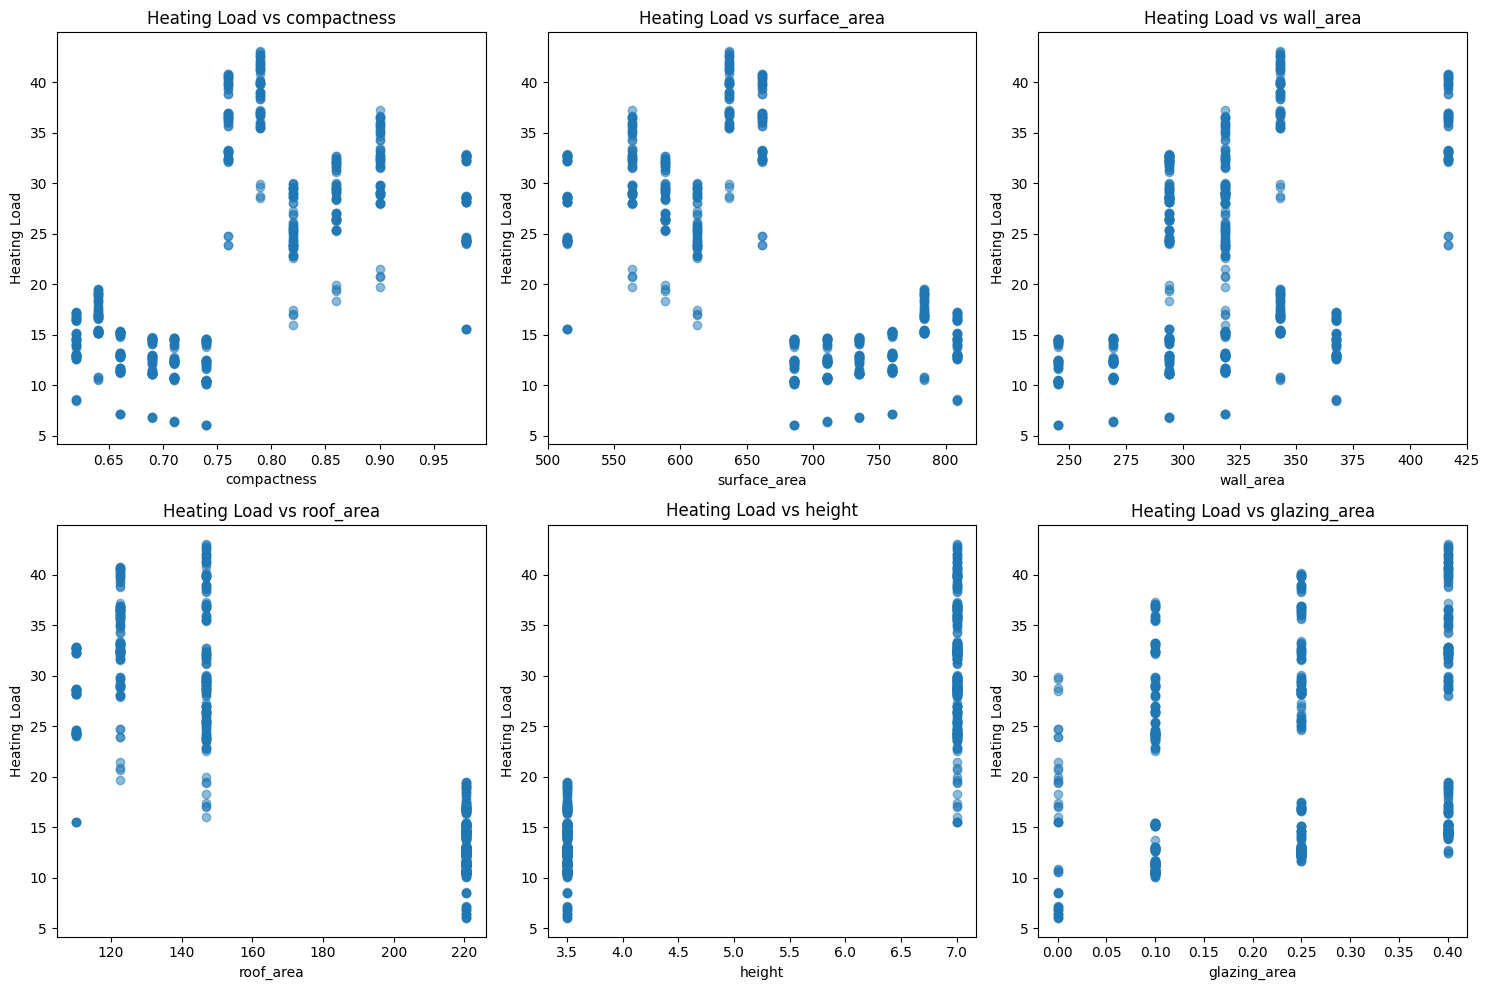

In [30]:
features = ['compactness', 'surface_area', 'wall_area', 'roof_area', 'height', 'glazing_area']

plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    plt.scatter(df[col], df['heating_load'], alpha=0.5)
    plt.title(f'Heating Load vs {col}')
    plt.xlabel(col)
    plt.ylabel('Heating Load')

plt.tight_layout()
plt.show()

### **1.2.3 Feature Selection — 4 Marks**
Based on your scatter plots, select **exactly 3 features** that appear to have the strongest relationship with `heating_load`. Store them in the `features` list below and briefly justify your choice in the space below.

**Rationale:**

In [31]:
features = ['compactness', 'roof_area', 'height']
print("Chosen features:", features)

Chosen features: ['compactness', 'roof_area', 'height']


## **1.3 Normalizing Data — 5 Marks**

### **1.3.1 Why Standardization?**
Standardization (z-score normalization) transforms each feature so that:
- **Mean = 0**

- **Standard Deviation = 1**

This ensures:
- Gradient descent converges faster and more stably.

- Features on different scales (e.g., `surface_area` in hundreds vs. `compactness` between 0 and 1) are treated fairly.

- Regularization penalties (L1/L2) are not dominated by large-scale features.
<br>

### **1.3.2 Implementation — 5 Marks**

Implement a custom `StandardScaler` class with two methods:

### `fit(X)`
- Compute the mean and standard deviation **only on the training set** (column-wise).

- Store these values as instance variables for use later.

### `transform(X)`
- Use the **stored training statistics** to standardize any dataset.

- Remember the formula: $$x_{\text{scaled}} = \dfrac{x - \mu}{\sigma}$$
<br>

⚠️ **Important:** You must fit **only** on training data and apply the same transform to the test set. Fitting on test data would be **data leakage**.

In [32]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)

    def transform(self, X):
        X_scaled = (X - self.mean) / self.std
        return X_scaled

## **1.4 Train/Test Split and Scaling — 5 Marks**

Before we proceed, we need to split the dataset into:
- **70% training data** — used to fit the model and scaler.

- **30% test data** — held out for final evaluation.

To do so, use `train_test_split` with `random_state=42`.

Then:
1. Fit the `StandardScaler` on **training features only**.
2. Transform both training and test features using the fitted scaler.

In [33]:
X_raw = df[features].to_numpy(dtype=float)
y = df['heating_load'].to_numpy(dtype=float).reshape(-1, 1)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (537, 3)
X_test shape: (231, 3)


## **1.5 Linear Regression Model — 20 Marks**

### **1.5.1 Understanding the Notation**
**Notation (shapes)**  
- Let $m$ = number of examples, $n$ = number of features (**here $n = 3$**).

- $X \in \mathbb{R}^{m \times (n+1)}$: standardized features with a **bias column** of 1s prepended.

- $\theta \in \mathbb{R}^{(n+1) \times 1}$: parameters where $\theta_0$ is the bias and $\theta_1, \ldots, \theta_n$ are the weights.

- $y \in \mathbb{R}^{m \times 1}$: targets (heating load).
<br>


**Hypothesis**

$$
\hat{y} = X\theta \quad \text{or equivalently} \quad \hat{y} = \theta^T x
$$

> Predicts the target as a weighted sum of features plus a bias.

<br>

**Loss (MSE with ½ factor)**

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\big(\hat y^{(i)} - y^{(i)}\big)^2
$$

> Measures how far our predictions are from the true values, averaged over all examples.

<br>

**Gradient**

Let $e = X\theta - y$. This is the prediction error vector.

<!-- $$
\nabla_{\theta} J(\theta) = \frac{1}{m}\ (X^\top X\theta - X^\top y)
$$ -->

$$
\nabla_{\theta} J(\theta)
=
\frac{1}{m}X^{\top}\!\big(\hat{y}-y\big)
$$

> Tells us the direction to adjust each parameter to reduce the loss.

<br>

**Batch Gradient Descent Update**

<!-- $$
\theta := \theta \;-\; \alpha \cdot \frac{1}{m}\,X^\top(X\theta - y).
$$ -->

$$
\theta := \theta - \alpha\,\nabla_{\theta}J(\theta)
$$

> Repeatedly updates parameters to minimize the loss.

<br>

**Key Idea**

Think of `θ` as "knobs" that we are to tune:

1. **Forward pass** → predictions `ŷ`

2. **Loss** → tells us how wrong we are  

3. **Gradient** → shows which way to turn the knobs  

4. **Gradient descent** → turns the knobs step by step to reduce error
<br>

### **1.5.2 Implementing a Linear Regression Model — 20 Marks**
You should now be ready to implement the `LinearRegression` class below. It must include:

- `__init__`: Set learning rate, random seed, and initialize storage for weights, bias, and cost history.

- `initialize_parameters`: Initialize $\theta_1, \ldots, \theta_n$ (randomly or to zeros) and $\theta_0 = 0$.

- `forward`: Compute predictions $\hat{y} = X\theta$.

- `compute_loss`: Compute $J = \frac{1}{2m}(X\theta - y)^T(X\theta - y)$ and **save** it to cost history.

- `backward`: Compute gradient $\nabla_\theta J(\theta) = \frac{1}{m} X^T(X\theta - y)$.

- `fit`: Run gradient descent for `iterations` steps. Each step: call `forward` → `compute_cost` → `backward` → update $\theta$.

- `predict`: Return $\hat{y}$ for new inputs using learned $\theta$.

- `score`: Compute and return MSE on given data.

In [34]:
class LinearRegression:
    def __init__(self, n_features, learning_rate=0.01, seed=42):
        self.n_features = n_features
        self.lr = learning_rate
        self.seed = seed
        self.W = None
        self.b = None
        self.cost_history = []
        self.dW = None
        self.db = None

    def initialize_parameters(self):
        np.random.seed(self.seed)
        self.W = np.random.randn(self.n_features, 1) * 0.01
        self.b = 0.0

    def forward(self, X):
        return np.dot(X, self.W) + self.b

    def compute_loss(self, predictions, y):
        m = y.shape[0]
        loss = (1 / (2 * m)) * np.sum(np.square(predictions - y))
        self.cost_history.append(loss)
        return loss

    def backward(self, X, predictions, y):
        m = y.shape[0]
        errors = predictions - y
        self.dW = (1 / m) * np.dot(X.T, errors)
        self.db = (1 / m) * np.sum(errors)

    def fit(self, X, y, iterations=1000):
        self.initialize_parameters()
        for _ in range(iterations):
            predictions = self.forward(X)
            self.compute_loss(predictions, y)
            self.backward(X, predictions, y)
            self.W -= self.lr * self.dW
            self.b -= self.lr * self.db
        return self

    def predict(self, X):
        return self.forward(X)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(np.square(predictions - y))

## **1.6 Training & Evaluation — 5 Marks**

Train your `LinearRegression` model and evaluate it:

- **Plot the cost curve** — MSE/2 vs. number of iterations. The curve should decrease and plateau (if it diverges, lower your learning rate).

- **Report MSE** on both the training and test sets.


💡 **Target performance:** Your train MSE should be approximately **9–13** and test MSE approximately **10–15**, depending on your feature choice. If you're far off, revisit your feature selection or learning rate.

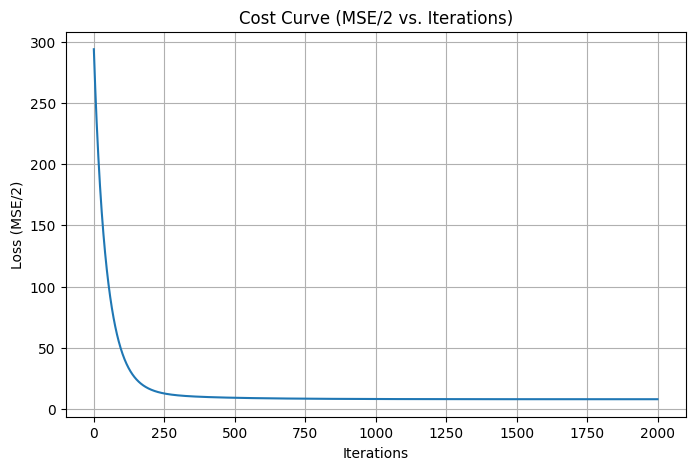

Training MSE: 16.1599
Test MSE: 15.9352


In [35]:
n_iterations = 2000
alpha = 0.01

model = LinearRegression(n_features=X_train.shape[1], learning_rate=alpha)
model.fit(X_train, y_train, iterations=n_iterations)

plt.figure(figsize=(8, 5))
plt.plot(range(len(model.cost_history)), model.cost_history)
plt.title('Cost Curve (MSE/2 vs. Iterations)')
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE/2)')
plt.grid(True)
plt.show()

train_mse = model.score(X_train, y_train)
test_mse = model.score(X_test, y_test)

print(f"Training MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

## **1.7 Linear Regression with Scikit-learn — 5 Marks**

Train an **Ordinary Least Squares (OLS)** linear regression model using `sklearn.linear_model.LinearRegression` on the same standardized training data.  

- Report **MSE** on both train and test sets.

- Print the model's learned coefficients and intercept.

- Compare these weights to the ones your from-scratch model learned.

In [36]:
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.metrics import mean_squared_error

sk_model = SKLinearRegression()
sk_model.fit(X_train, y_train)

y_train_pred = sk_model.predict(X_train)
y_test_pred = sk_model.predict(X_test)

train_mse_sk = mean_squared_error(y_train, y_train_pred)
test_mse_sk = mean_squared_error(y_test, y_test_pred)

print(f"Scikit-learn Training MSE: {train_mse_sk:.4f}")
print(f"Scikit-learn Test MSE: {test_mse_sk:.4f}")

print(f"Scikit-learn Coefficients: {sk_model.coef_}")
print(f"Scikit-learn Intercept: {sk_model.intercept_}")

print(f"From-scratch Coefficients: {model.W.flatten()}")
print(f"From-scratch Intercept: {model.b}")

Scikit-learn Training MSE: 16.1482
Scikit-learn Test MSE: 15.8988
Scikit-learn Coefficients: [[-4.64956932 -5.13024929  7.82384793]]
Scikit-learn Intercept: [22.05050279]
From-scratch Coefficients: [-4.54436984 -5.40844235  7.441043  ]
From-scratch Intercept: 22.050502752199293


# **<span style="color:#008080;">2. Predicting Success with Logistic Regression — 50 Marks</span>**

Ever wondered what determines your grades? Interest? Time? Caffeine? In this assignment, you'll build a **Logistic Regression model** to use features like these to predict student grades.

**Allowed Libraries:**
- From-scratch implementation: `numpy`, `pandas`, `matplotlib`, `mpl_toolkits`, `seaborn`. You may import `sklearn.model_selection.train_test_split` for splitting and `sklearn.metrics` for evaluation.

- Scikit-learn implementation: `scikit-learn`.

## **2.1 Understanding the Student Success Dataset**

This dataset models student lifestyle, academic habits, and engagement factors to analyze their relationship with academic performance. Each row represents an individual student and their associated behavioral and academic attributes.

The goal is to predict the student’s **final grade** — a **categorical target variable** representing overall academic performance.
<br><br>

**Features:**

| Column | Description |
|---|---|
| age | Student’s age in years. |
| num_notebooks | Number of notebooks actively used for coursework (0–4). |
| num_friends | Size of close friend circle (0–4). |
| travel_time | Travel time to campus (1–4 scale). |
| chai_cups_daily | Daily tea consumption (1–4 cups). |
| total_f_grades | Total number of F grades previously received (0–3). |
| hangouts | Weekly social outings (1–5). |
| societies | Number of student societies participated in (1–5). |
| TAships | Number of teaching assistant roles completed (1–5). |
| health | Self-reported health level (1–5 scale). |
| absences | Total recorded absences (0–33). |
| times_cheated | Number of reported cheating incidents (0–18). |
| study_time | Weekly study hours (5–19). |
| love_for_ai_ml | Interest level in AI/ML (0–17 scale). |
| grade (target) | Final course grade (A, B, C, D, E). |

<br><br>
**Start by importing the required libraries:**

In [37]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

ModuleNotFoundError: No module named 'seaborn'

**Load the dataset here.** Take some time to explore its features.

In [ ]:
df_students = pd.read_csv('students_data.csv')

print(df_students.info())
print(df_students.describe())
print(df_students.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              500 non-null    int64 
 1   num_notebooks    500 non-null    int64 
 2   num_friends      500 non-null    int64 
 3   travel_time      500 non-null    int64 
 4   chai_cups_daily  500 non-null    int64 
 5   total_f_grades   500 non-null    int64 
 6   hangouts         500 non-null    int64 
 7   societies        500 non-null    int64 
 8   TAships          500 non-null    int64 
 9   health           500 non-null    int64 
 10  absences         500 non-null    int64 
 11  times_cheated    500 non-null    int64 
 12  study_time       500 non-null    int64 
 13  love_for_ai/ml   500 non-null    int64 
 14  grade            500 non-null    object
dtypes: int64(14), object(1)
memory usage: 58.7+ KB
None
              age  num_notebooks  num_friends  travel_time  chai_cups_dai

## **2.2 Preprocessing the Data — 5 Marks**

Before building the model, the dataset must be properly prepared for analysis.
<br>

### **2.2.1 Train/Test Split — 2 Marks**  
Split the dataset into training and testing sets using an 80:20 ratio. After splitting, verify and report the sizes of both sets. This ensures that the model is trained on one portion of the data and evaluated on unseen data. **Remember that `grade` is the target variable.**

In [ ]:
X = df_students.drop(columns=['grade'])
y = df_students['grade']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train_raw.shape[0]}")
print(f"Testing set size: {X_test_raw.shape[0]}")

Training set size: 400
Testing set size: 100


### **2.2.2 Feature Normalization — 3 Marks**  
Use the `StandardScaler` class implemented in **Section 1.3.2** to standardize the feature values. Fit the scaler on the training data, and apply the same transformation to the test data.

⚠️ **Important:** You must fit **only** on training data and apply the same transform to the test set. Fitting on test data would be **data leakage**.

In [ ]:
scaler_logistic = StandardScaler()
scaler_logistic.fit(X_train_raw.to_numpy())

X_train = scaler_logistic.transform(X_train_raw.to_numpy())
X_test = scaler_logistic.transform(X_test_raw.to_numpy())

print(f"Standardized X_train sample:\n{X_train[:2]}")
print(f"Standardized X_test sample:\n{X_test[:2]}")

Standardized X_train sample:
[[-1.47631818 -1.39502355  1.37314358  0.41469811  0.48231168 -0.74035776
  -1.48683041  1.5165097   0.79628448  1.47193706  0.41550999  0.82488569
  -0.25466123 -0.19580216]
 [-0.00977694 -1.39502355  0.66350865 -1.4284046   1.38806132 -0.74035776
  -0.02197286 -1.37552311 -0.64822251  1.47193706 -0.72959627  1.63458943
   1.42904939  1.49945464]]
Standardized X_test sample:
[[-0.00977694  1.40904389 -0.75576119  1.33624946  0.48231168 -0.74035776
   1.44288468  0.0704933  -0.64822251  0.02709087 -1.38394271  0.01518195
   0.16626642  0.48230056]
 [-0.00977694  0.00701017 -1.46539612 -1.4284046  -0.42343795 -0.74035776
  -1.48683041  0.7935015   1.51853797 -0.69533223 -0.40242306 -0.38966993
  -0.67558889  0.1432492 ]]


## **2.3 Logistic Regression Model — 20 Marks**

### **2.3.1 Understanding the Notation**

**Notation (shapes)**

- $m$ = number of training examples

- $n$ = number of features

- $X \in \mathbb{R}^{m \times (n+1)}$: feature matrix with bias column of 1s prepended

- $\theta \in \mathbb{R}^{(n+1) \times 1}$: parameter vector where $\theta_0$ is the bias and $\theta_1, \ldots, \theta_n$ are the weights

- $y \in \mathbb{R}^{m \times 1}$: true labels (0 or 1)

- $\hat{y} \in \mathbb{R}^{m \times 1}$: predicted probabilities  
<br>

**Model**

$$
\hat{y} = \sigma(\theta^T x), \qquad
\sigma(z) = \frac{1}{1 + e^{-z}}
$$  

> Logistic regression first computes a linear combination of features, then converts it into a probability.

<br>

**Loss (Binary Cross-Entropy)**

$$
J(\theta)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\Big[
y^{(i)} \log \hat{y}^{(i)}
+
\big(1-y^{(i)}\big)\log\!\big(1-\hat{y}^{(i)}\big)
\Big],
\qquad
\hat{y} = \sigma(X\theta)
$$

> Cross-entropy measures how well predicted probabilities match actual outcomes.

<br>

**Gradient**

$$
\nabla_{\theta} J(\theta)
=
\frac{1}{m}X^{\top}\!\big(\hat{y}-y\big)
$$

> Gradients indicate the direction that reduces the loss most efficiently.

<br>

**Update (Gradient Descent)**

$$
\theta := \theta - \alpha\,\nabla_{\theta}J(\theta)
$$

> Repeating this process gradually improves class separation and minimizes the loss.

<br>

**Key Idea**

At each iteration, the model:
1. Computes predictions

2. Computes loss

3. Computes gradients

4. Updates parameters
<br>

### **2.3.2 Implementing a Logistic Regression Model**

You should now be equipped with the information required to implement the functionality described below to create a fully-fledged **Logistic Regression model.** This class contains:

* `sigmoid(x)`: This is the non-linear "activation" function that differentiates Logistic from plain-old Linear Regression. Refer to the formula from the slides.

* `cross_entropy_loss(y_true, y_pred)`: This is the loss function that will help you calculate the gradients for updating your model.

* `fit(x_train, y_train)`: This will be where you implement the Gradient Descent algorithm again, keeping in mind the differences between Linear and Logistic Regression. Keep track of losses for every iteration: you can save them in the class or return them.

* `predict(x_test)`: predict whether the grade label is 0 or 1 for the student feature record using learned logistic regression (use the decision threshold of 0.5) **Note: you need to return the probability and the predicted label from this function.**

* `evaluate(y_true, y_pred)` function that calculates classification accuracy, F1 Score and confusion matrix. You can use `sklearn.metrics` for this.

In [ ]:
class LogisticRegression:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.theta = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        m, n = X.shape
        X_bias = np.c_[np.ones((m, 1)), X]
        self.theta = np.zeros((n + 1, 1))
        y = y.values.reshape(-1, 1) if isinstance(y, pd.Series) else y.reshape(-1, 1)

        for _ in range(self.iterations):
            z = np.dot(X_bias, self.theta)
            y_pred = self.sigmoid(z)

            loss = self.cross_entropy_loss(y, y_pred)
            self.loss_history.append(loss)

            gradient = (1/m) * np.dot(X_bias.T, (y_pred - y))
            self.theta -= self.lr * gradient

    def predict(self, X):
        m = X.shape[0]
        X_bias = np.c_[np.ones((m, 1)), X]
        probabilities = self.sigmoid(np.dot(X_bias, self.theta))
        labels = (probabilities >= 0.5).astype(int)
        return probabilities, labels

    def evaluate(self, y_true, y_pred_labels):
        accuracy = accuracy_score(y_true, y_pred_labels)
        f1 = f1_score(y_true, y_pred_labels, average='weighted')
        cm = confusion_matrix(y_true, y_pred_labels)
        return accuracy, f1, cm

## **2.4 One vs All Classification — 5 Marks**

In this section, you need to build a classifier per class (grade) perform the following steps for each:

1. Create a plot with the number of iterations/epochs on the x-axis and training/validation loss on the y-axis for the evaluation dataset that we separated previously.

2. Tune the hyperparameters, i.e., learning rate and number of epochs, to minimize the train loss.

**Recall that:**
- Your Logistic Regression classifier is **binary** and you are trying to do one-vs-all classification, so the grade labels will need some tweaking for every classifier.

**Please note that the correctness of the functions you created previously depends on the plot. The curve should show a constant dip, eventually reaching a plateau.**


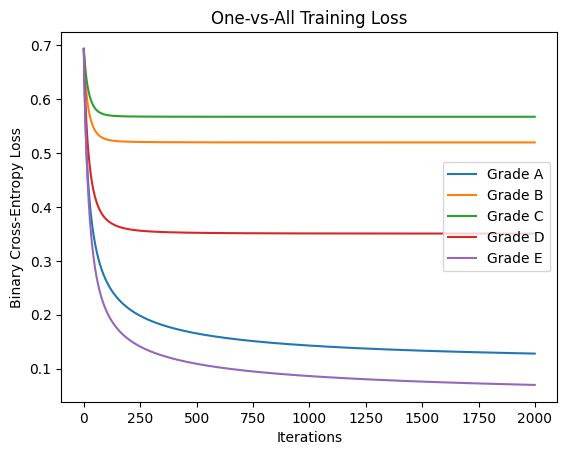

In [ ]:
classifiers = {}
unique_grades = np.unique(y_train)

for grade in unique_grades:
    y_train_binary = (y_train == grade).astype(int)

    model = LogisticRegression(lr=0.1, iterations=2000)
    model.fit(X_train, y_train_binary)

    classifiers[grade] = model

    plt.plot(model.loss_history, label=f'Grade {grade}')

plt.title('One-vs-All Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.show()

## **2.5 Evaluation — 15 Marks**

### **2.5.1 Class-wise Evaluation — 10 Marks**
Evaluate each binary classifier on the test data.

In [ ]:
for grade, model in classifiers.items():
    y_test_binary = (y_test == grade).astype(int)
    probs, labels = model.predict(X_test)

    accuracy, f1, cm = model.evaluate(y_test_binary, labels)

    print(f"--- Grade {grade} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

--- Grade A Evaluation ---
Accuracy: 0.9100
F1 Score: 0.9064
Confusion Matrix:
[[80  3]
 [ 6 11]]

--- Grade B Evaluation ---
Accuracy: 0.7100
F1 Score: 0.6374
Confusion Matrix:
[[70  5]
 [24  1]]

--- Grade C Evaluation ---
Accuracy: 0.6600
F1 Score: 0.5725
Confusion Matrix:
[[66  6]
 [28  0]]

--- Grade D Evaluation ---
Accuracy: 0.7400
F1 Score: 0.7400
Confusion Matrix:
[[71 13]
 [13  3]]

--- Grade E Evaluation ---
Accuracy: 0.9500
F1 Score: 0.9453
Confusion Matrix:
[[86  0]
 [ 5  9]]



### **2.5.2 Multi-class Evaluation — 5 Marks**

Perform multiclass evaluation and produce a confusion matrix. Also report macro-F1 and accuracy scores. **You should be able to achieve a minimum score of 0.6 for accuracy and 0.59 for macro-F1.**

Overall Accuracy: 0.6100
Macro-F1 Score: 0.6086

Multi-class Confusion Matrix:
[[14  3  0  0  0]
 [ 4 16  5  0  0]
 [ 0  5 18  5  0]
 [ 0  0  9  6  1]
 [ 0  0  1  6  7]]


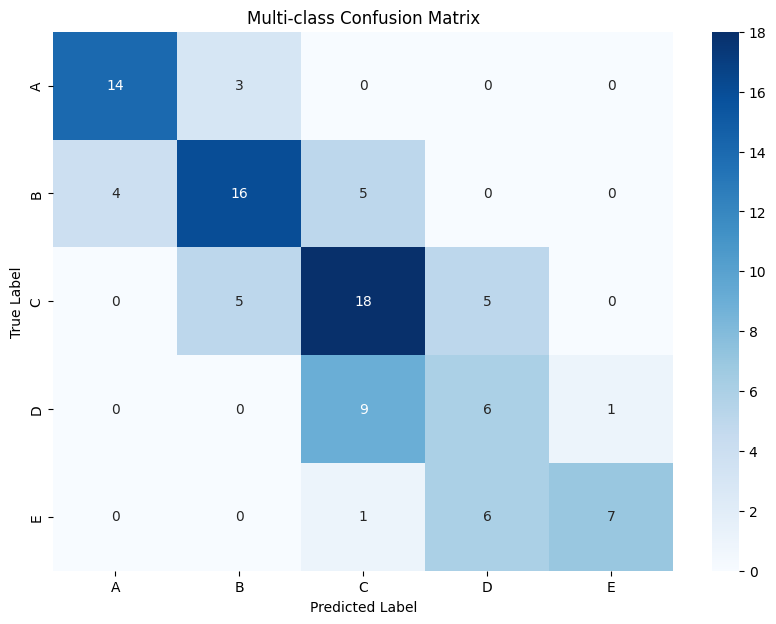

In [ ]:
all_probs = []
grade_list = sorted(classifiers.keys())

for grade in grade_list:
    probs, _ = classifiers[grade].predict(X_test)
    all_probs.append(probs)

all_probs = np.hstack(all_probs)
final_predictions = np.array([grade_list[i] for i in np.argmax(all_probs, axis=1)])

accuracy = accuracy_score(y_test, final_predictions)
macro_f1 = f1_score(y_test, final_predictions, average='macro')
conf_matrix = confusion_matrix(y_test, final_predictions, labels=grade_list)

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro-F1 Score: {macro_f1:.4f}")
print("\nMulti-class Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=grade_list, yticklabels=grade_list, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multi-class Confusion Matrix')
plt.show()

## **2.6 Logistic Regression with Scikit-learn — 5 Marks**

Finally, use `scikit-learn`’s [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) on the same standardised data. At the end, report accuracy and F1 scores, and plot a confusion matrix summarising your results.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Scikit-learn Accuracy: 0.6500
Scikit-learn Macro-F1: 0.6621


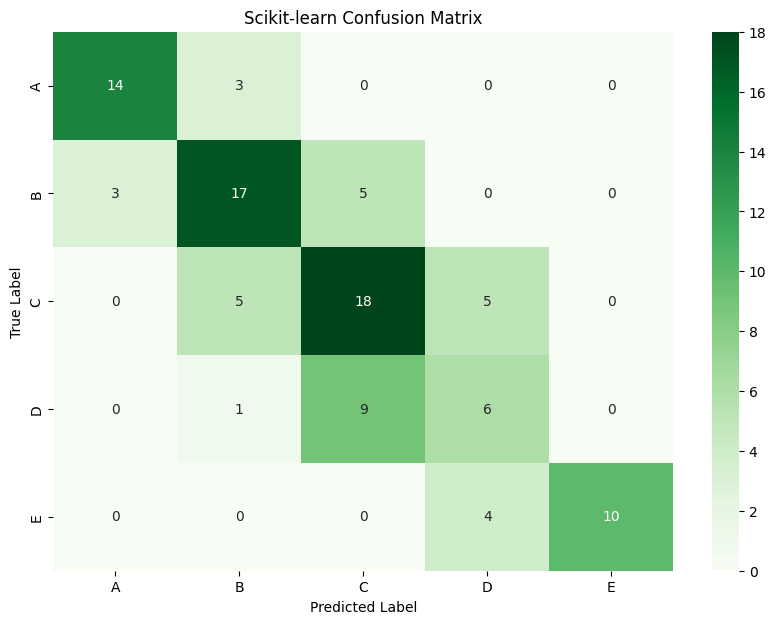

In [ ]:
from sklearn.linear_model import LogisticRegression as SKLogisticRegression

sk_logit = SKLogisticRegression(multi_class='ovr', max_iter=2000)
sk_logit.fit(X_train, y_train)

y_pred_sk = sk_logit.predict(X_test)

accuracy_sk = accuracy_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk, average='macro')
conf_matrix_sk = confusion_matrix(y_test, y_pred_sk, labels=sk_logit.classes_)

print(f"Scikit-learn Accuracy: {accuracy_sk:.4f}")
print(f"Scikit-learn Macro-F1: {f1_sk:.4f}")

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_sk, annot=True, fmt='d', xticklabels=sk_logit.classes_, yticklabels=sk_logit.classes_, cmap='Greens')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Scikit-learn Confusion Matrix')
plt.show()